In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, exp, sqrt, abs, real, imag
from scipy.fft import fft2, ifft2, fftfreq
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT

In [2]:
N = 2**5
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)


In [3]:
# ========== 初始化量子态 ==========
initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state = initial_state / np.linalg.norm(initial_state)

# ========== 傅里叶频率 ==========
kx = fftfreq(N, d=(2*pi/N)) * N
ky = fftfreq(N, d=(2*pi/N)) * N
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
dt = 0.0
U = np.exp(-1j * K2 * dt / 2)

# ========== 经典谱方法 ==========
def evolve_spectral(psi, U):
    psi_hat = fft2(psi)
    psi_hat_new = psi_hat * U
    return ifft2(psi_hat_new)

psi1_classic = evolve_spectral(psi1_0, U)
psi2_classic = evolve_spectral(psi2_0, U)

# ========== 量子算法 A ==========
def kinetic_operator(n, dt):
    qc = QuantumCircuit(n)
    qc.rz(-2**(n-1)*dt, n-1)
    for i in range(n):
        qc.rz(2**(n-i-2)*dt, n-i-1)
    for i in range(1, n):
        qc.cx(n-1, n-i-1)
        qc.rz(-2**(2*n-i-2)*dt, n-i-1)
        qc.cx(n-1, n-i-1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n-i-1, n-j-1)
                qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                qc.cx(n-i-1, n-j-1)
    return qc

def evolve_quantum(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()
    circ.append(QFT(nx), range(nx))
    circ.append(QFT(ny), range(nx, nx+ny))
    circ.barrier()
    circ.append(kinetic_operator(nx, dt), range(nx))
    circ.append(kinetic_operator(ny, dt), range(nx, nx+ny))
    circ.barrier()
    circ.append(QFT(nx).inverse(), range(nx))
    circ.append(QFT(ny).inverse(), range(nx, nx+ny))
    circ.save_state()

    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    statevector = result.data(0)['statevector']
    tmp = np.array(statevector).reshape(2, N, N)
    return tmp[0], tmp[1]


In [4]:
psi1_quantum, psi2_quantum = evolve_quantum(5, 5, dt, initial_state)

# 统一质量归一化，修正缩放误差
rho_q = abs(psi1_quantum)**2 + abs(psi2_quantum)**2
rho_c = abs(psi1_classic)**2 + abs(psi2_classic)**2
scale = np.sqrt(np.sum(rho_c) / np.sum(rho_q))
psi1_quantum *= scale
psi2_quantum *= scale


✅ Fidelity (ψ⁺+ψ⁻): 1.000000
✅ L2 Error in ψ⁺: 1.295e-15
✅ L2 Error in ψ⁻: 8.645e-16


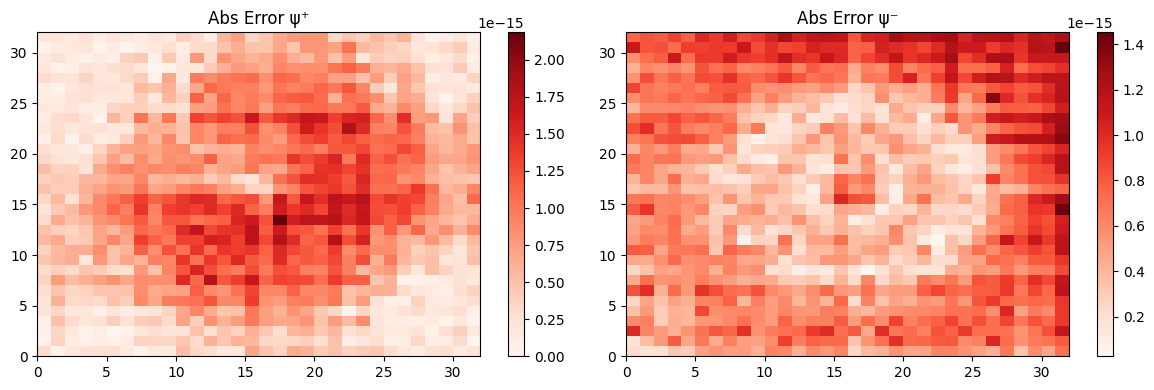

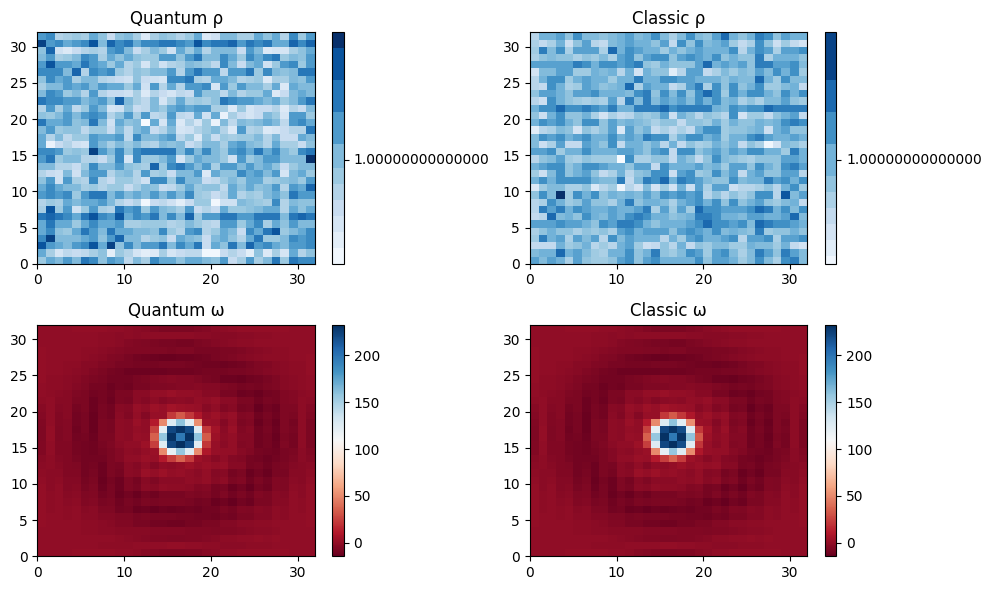

In [5]:
# ========== 精度评估 ==========
def compute_fidelity(psi1a, psi2a, psi1b, psi2b):
    a = (psi1a + psi2a).flatten()
    b = (psi1b + psi2b).flatten()
    a /= np.linalg.norm(a)
    b /= np.linalg.norm(b)
    return np.abs(np.vdot(a, b))**2

def compute_L2_error(psi1a, psi1b):
    return np.linalg.norm(psi1a - psi1b) / np.linalg.norm(psi1b)

fidelity = compute_fidelity(psi1_quantum, psi2_quantum, psi1_classic, psi2_classic)
error_psi1 = compute_L2_error(psi1_quantum, psi1_classic)
error_psi2 = compute_L2_error(psi2_quantum, psi2_classic)

print(f"✅ Fidelity (ψ⁺+ψ⁻): {fidelity:.6f}")
print(f"✅ L2 Error in ψ⁺: {error_psi1:.3e}")
print(f"✅ L2 Error in ψ⁻: {error_psi2:.3e}")

# ========== 误差图 ==========
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Abs Error ψ⁺")
plt.pcolormesh(abs(psi1_quantum - psi1_classic), cmap='Reds')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Abs Error ψ⁻")
plt.pcolormesh(abs(psi2_quantum - psi2_classic), cmap='Reds')
plt.colorbar()
plt.tight_layout()
plt.show()

# ========== 输出ρ和ω ==========
def compute_rho_omega(psi1, psi2):
    rho = abs(psi1)**2 + abs(psi2)**2
    dpsi1_x = ifft2(1j*KX*fft2(psi1))
    dpsi1_y = ifft2(1j*KY*fft2(psi1))
    dpsi2_x = ifft2(1j*KX*fft2(psi2))
    dpsi2_y = ifft2(1j*KY*fft2(psi2))
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x)
            + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y)
            + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    omega = real(ifft2(1j*KX*fft2(uy) - 1j*KY*fft2(ux)))
    return rho, omega

rho_q, omega_q = compute_rho_omega(psi1_quantum, psi2_quantum)
rho_c, omega_c = compute_rho_omega(psi1_classic, psi2_classic)

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.title("Quantum ρ")
plt.pcolormesh(rho_q, cmap='Blues')
plt.colorbar()

plt.subplot(2, 2, 2)
plt.title("Classic ρ")
plt.pcolormesh(rho_c, cmap='Blues')
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("Quantum ω")
plt.pcolormesh(omega_q, cmap='RdBu')
plt.colorbar()

plt.subplot(2, 2, 4)
plt.title("Classic ω")
plt.pcolormesh(omega_c, cmap='RdBu')
plt.colorbar()
plt.tight_layout()
plt.show()

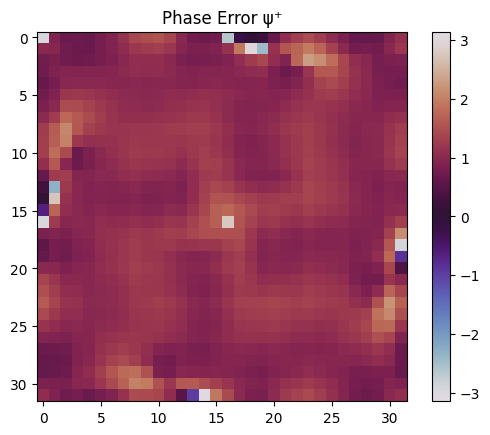

In [14]:
def compute_phase_error(psi1a, psi1b):
    phase_a = np.angle(psi1a)
    phase_b = np.angle(psi1b)
    phase_diff = np.angle(np.exp(1j*(phase_a - phase_b)))  # wrap to [-pi, pi]
    return phase_diff

# 可视化
phase_err = compute_phase_error(psi1_quantum, psi1_classic)
plt.imshow(phase_err, cmap='twilight', vmin=-np.pi, vmax=np.pi)
plt.title("Phase Error ψ⁺")
plt.colorbar()


Text(0.5, 1.0, 'Quantum Streamlines')

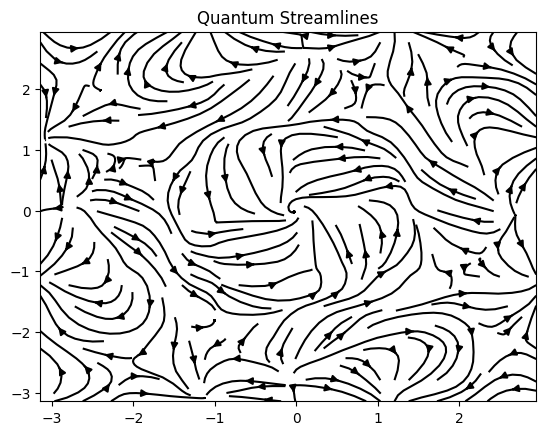

In [15]:
def compute_velocity(psi1, psi2):
    rho = abs(psi1)**2 + abs(psi2)**2
    dpsi1_x = ifft2(1j*KX*fft2(psi1))
    dpsi1_y = ifft2(1j*KY*fft2(psi1))
    dpsi2_x = ifft2(1j*KX*fft2(psi2))
    dpsi2_y = ifft2(1j*KY*fft2(psi2))
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x)
              + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y)
              + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    return ux, uy

# 可视化
ux_q, uy_q = compute_velocity(psi1_quantum, psi2_quantum)
plt.streamplot(x, y, ux_q, uy_q, density=1.2, color='k')
plt.title("Quantum Streamlines")


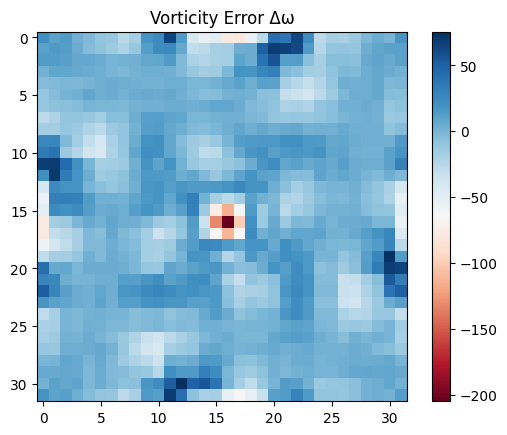

In [16]:
omega_q = compute_rho_omega(psi1_quantum, psi2_quantum)[1]
omega_c = compute_rho_omega(psi1_classic, psi2_classic)[1]
omega_err = omega_q - omega_c
plt.imshow(omega_err, cmap='RdBu')
plt.title("Vorticity Error Δω")
plt.colorbar()
